Initialization paths...
All paths was initialized.
Load 'sign' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_sign.csv
Load 'label' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_label.csv
Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv
Loading & preparing image data...

Cropping & loading labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m/Sentinel/tiles/39UVV/2023_03_01/comp_s2_90d_b2_l2a_med.frag.0.tif
Files was loaded.
Loading from cache...
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/labels/landcover23c_v571_2023.Samara.tif
Files was loaded.
Crop labels is done.

Resizing labels by 1st image:
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/images_10m

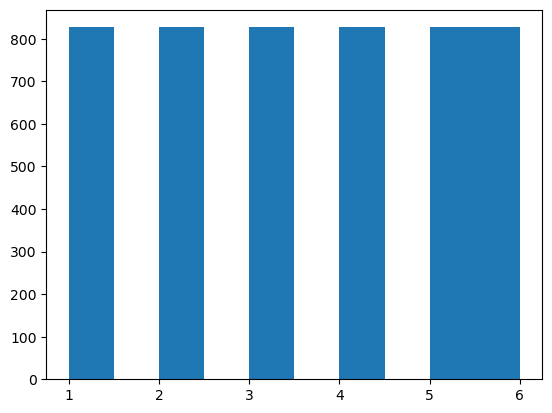

In [1]:
from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *

force = False
downgrade_labels = force

if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching)
    DEFAULT_PATH["labels"] = out

# you can use force=True for re-write all caches.
signs = parse_tifs_from(DEFAULT_PATH["images"], "sign", force=force)
signs = signs.query("type == 'sign'")

labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=force)
labels = labels.query("type == 'label'")

year = 2023
only_bands = ["r", "b", "g", "n"]
mask_mode = "secure"
layer_mode = "texture"
stratify = True
resize = "by_sign"
r = 20
homogen_percent = 1
percent_assign = 0.1

signs_paths = (
    signs.query(f"year == {year} and season == 'mon' and band in @only_bands")
    .sort_values("month")
    .sort_values("band")
)
labels_paths = labels.query(f"year == {year}")

# for 10m low RAM load
only_bands = ["r", "b", "g", "n"]
tiles = DEFAULT_PATH["images"] + "tiles/"
tiles = parse_tifs_from(tiles, typeof="tile", force=force)
tiles = (
    tiles.query(f"year == {year} and band in @only_bands")
    .sort_values("month")
    .sort_values("band")
)
signs_paths = tiles

z_x, z_y, x, y = generate_dataset(
    signs_paths,
    labels_paths,
    percent_assign,
    mask_mode=mask_mode,
    layer_mode=layer_mode,
    layer_type="static",
    resize=resize,
    r=r,
    stratify=stratify,
    homogen_percent=homogen_percent,
    force=force,
    verbose=True,
    save_mask=True,
)

uniq_type, uniq_count = np.unique(z_y, return_counts=True)
print(uniq_type, uniq_count)
plt.hist(z_y)
plt.show()

Split X, y -> X_train, y_train...
Start training model...
Selected model / method: RF
Model was trained. Start validate it...

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.89      0.88       148
           2       0.81      0.84      0.82       180
           3       0.70      0.64      0.67       175
           4       0.97      0.96      0.97       157
           5       0.87      0.93      0.90       167
           6       0.96      0.93      0.94       166

    accuracy                           0.86       993
   macro avg       0.86      0.86      0.86       993
weighted avg       0.86      0.86      0.86       993

Confusion Matrix:
[[132   0  14   1   1   0]
 [  2 151  27   0   0   0]
 [ 16  34 112   2  10   1]
 [  2   1   0 151   3   0]
 [  1   1   4   1 155   5]
 [  0   0   2   0  10 154]]
Saving model...
Model was saved: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/tmp_weights_RF.joblib


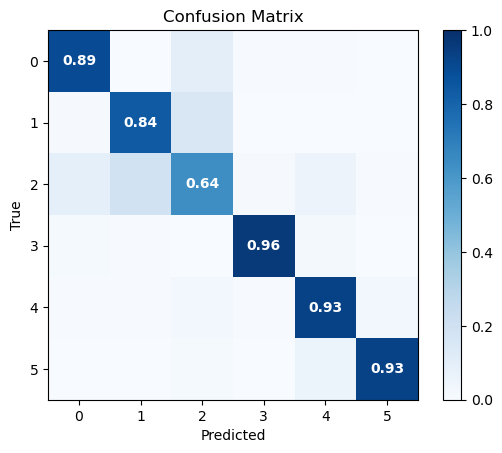

In [2]:
m, m_rep, m_cm, f1 = train_model(z_x, z_y)
plot_confusion(m_cm)

In [3]:
only_bands = ["r", "b", "g", "n"]
tiles = DEFAULT_PATH["images"] + "tiles/"
tiles = parse_tifs_from(tiles, typeof="tile", force=force)
tiles = (
    tiles.query(f"year == {year} and band in @only_bands")
    .sort_values("month")
    .sort_values("band")
)

out = f"handle_10m_{mask_mode}_stratify_{stratify}_f1_{f1:.2f}.tif"
out = DEFAULT_PATH["output"] + out
predicted = create_map(tiles, m, out, layer_mode="texture")

Load 'tile' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_tile.csv


UndefinedVariableError: name 'b4' is not defined

Load 'etalon' from cached DataFrame to path:  /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/path2tif_etalon.csv
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1_0.85.tif
Files was loaded.
Etalons will be loaded from cache.
Loading file: /Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/cropped/etalons/r36000.2023.dw.cor.tif
Files was loaded.
              precision    recall  f1-score   support

           1       0.98      0.71      0.83  34482382
           2       0.95      0.81      0.87  46985993
           3       0.39      0.84      0.54  14065426
           4       0.73      0.91      0.81   3420923
           5       0.49      0.59      0.54   5707535
           6       0.07      0.04      0.05   3469912

    accuracy                           0.75 108132171
   macro avg       0.60      0.65      0.61 108132171
weighted avg       0.83      0.75      0.77 108132171



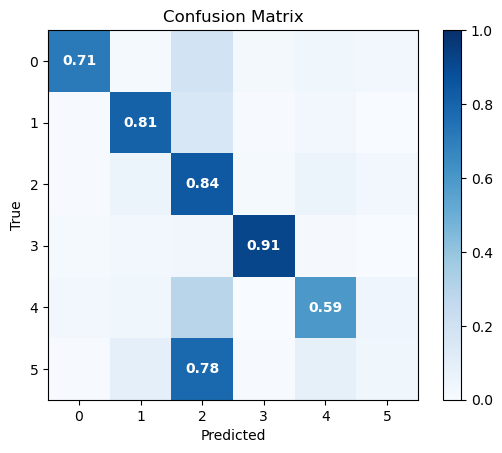

In [ ]:
# Module: validation
from validation import *
from visualisation import *

year = 2023
map = "dw"
force = False

# predicted = "/Users/stephenhawking/Coding/ML/low2high_map/src/../data/output/handle_10m_secure_stratify_True_f1_0.80.tif"
etalons = DEFAULT_PATH["etalons"]
etalons = parse_tifs_from(etalons, typeof="etalon", force=force)
etalons = etalons.query(f"year == {year} and map =='{map}'")["path"].to_list()
r = validate_how_tif(predicted, etalons, force=force)
# create_diff_map(predicted, etalons, "positive")
# create_diff_map(predicted, etalons, "negative")

plot_confusion(r["r36000.2023.dw.cor.tif"]["cf_matrix"])
print(r["r36000.2023.dw.cor.tif"]["report"])

In [19]:
etalons

['/Users/stephenhawking/Coding/ML/low2high_map/src/../data/input/etalons/r36000.2020.wc.cor.tif']

In [ ]:
# for 10m low RAM load
# automate create of maps

from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *
from tqdm import tqdm

downgrade_labels = False
force = False
if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching)
    DEFAULT_PATH["labels"] = out

# Base settings for all settings.
year = 2020
map = "wc"
force = False
verbose = False
etalons = DEFAULT_PATH["etalons"]
etalons = parse_tifs_from(etalons, typeof="etalon", force=True)
etalons = etalons.query(f"year == '{year}' and map =='{map}'")["path"].to_list()

only_bands = ["r", "b", "g", "n"]
tiles = DEFAULT_PATH["images"] + "tiles/"
tiles = parse_tifs_from(tiles, typeof="tile", force=True)
tiles = tiles.query("band in @only_bands").sort_values("month").sort_values("band")
signs_paths = tiles

labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=True)
labels = labels.query("type == 'label'")
labels_paths = labels.query(f"year == {year}")
# end base settings


# Parameter sets to cycle through
settings = [
    {
        "mask_mode": "random",
        "stratify": True,
        "resize": "by_sign",
        "r": 1,
        "homogen_percent": 1,
        "percent_assign": 0.001,
    },
    {
        "mask_mode": "random",
        "stratify": False,
        "resize": "by_sign",
        "r": 1,
        "homogen_percent": 1,
        "percent_assign": 0.0001,
    },
    {
        "mask_mode": "secure",
        "stratify": True,
        "resize": "by_sign",
        "r": 50,
        "homogen_percent": 1,
        "percent_assign": 0.1,
    },
    {
        "mask_mode": "secure",
        "stratify": True,
        "resize": "by_sign",
        "r": 90,
        "homogen_percent": 1,
        "percent_assign": 0.1,
    },
    {
        "mask_mode": "secure",
        "stratify": False,
        "resize": "by_sign",
        "r": 20,
        "homogen_percent": 1,
        "percent_assign": 0.0001,
    },
    {
        "mask_mode": "homogeneous",
        "stratify": True,
        "resize": "by_sign",
        "r": 1,
        "homogen_percent": 0.01,
        "percent_assign": 1,
    },
    {
        "mask_mode": "homogeneous",
        "stratify": False,
        "resize": "by_sign",
        "r": 1,
        "homogen_percent": 0.1,
        "percent_assign": 0.01,
    },
]

res = {}

for s in tqdm(settings, desc="Parameter sets"):
    mask_mode = s["mask_mode"]
    stratify = s["stratify"]
    resize = s["resize"]
    r = s["r"]
    homogen_percent = s["homogen_percent"]
    percent_assign = s["percent_assign"]

    z_x, z_y, x, y = generate_dataset(
        signs_paths,
        labels_paths,
        percent_assign,
        mask_mode=mask_mode,
        resize=resize,
        r=r,
        stratify=stratify,
        homogen_percent=homogen_percent,
        force=force,
        verbose=verbose,
    )

    uniq_type, uniq_count = np.unique(z_y, return_counts=True)
    print(
        f"mask_mode={mask_mode}, stratify={stratify}, resize={resize}, r={r}, homogen_percent={homogen_percent}, percent_assign={percent_assign}"
    )
    print(uniq_type, uniq_count)
    plt.hist(z_y)
    plt.show()

    m, m_rep, m_cm, f1 = train_model(z_x, z_y)
    plot_confusion(m_cm)

    resize_out = "10m" if resize == "by_sign" else "230m"
    out = f"auto_{resize_out}_{mask_mode}_stratify_{stratify}_f1_{f1:.2f}.tif"
    out = DEFAULT_PATH["output"] + out
    predicted = create_map(tiles, m, out)

    print("Validate it...")
    r_val = validate_how_tif(predicted, etalons, force=force)

    # Store results for later analysis
    res_key = (
        f"{mask_mode}_stratify_{stratify}_{resize}_{homogen_percent}_{percent_assign}%"
    )
    res[res_key] = {
        "cf_matrix": r_val["r36000.2020.wc.cor.tif"]["cf_matrix"],
        "report": r_val["r36000.2020.wc.cor.tif"]["report"],
        "f1": f1,
        "model": m,
        "out_path": out,
    }

    plot_confusion(r_val["r36000.2020.wc.cor.tif"]["cf_matrix"])
    print(r_val["r36000.2020.wc.cor.tif"]["report"])


KeyboardInterrupt: 